## Part 1: Environment setup

In [1]:
import sys
print(sys.executable)

/opt/conda/bin/python


#### Try spark image

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Hive Test") \
    .enableHiveSupport() \
    .getOrCreate()

print(spark.version)

spark.sql("SHOW DATABASES").show()

3.5.0
+---------------+
|      namespace|
+---------------+
|        default|
|maternal_health|
|         testdb|
+---------------+



#### Create database

In [3]:
spark.sql("CREATE DATABASE IF NOT EXISTS testdb")
spark.sql("SHOW DATABASES").show()

+---------------+
|      namespace|
+---------------+
|        default|
|maternal_health|
|         testdb|
+---------------+



#### Working directory

In [4]:
import os
os.getcwd()

'/home/jovyan'

#### Workflow:
+ CSV Dataset -> Spark DataFrame -> Data Cleaning -> Hive Table -> Spark SQL Queries -> Visualizations -> Insight & Recommendations 

## Part 2: Dataset overview
+ The Maternal Health Risk dataset is a healthcare dataset obtained from the UCI Machine Learning Repository and is designed for multiclass classification tasks. It contains 1,013 patient records with six clinical predictor variables and one target variable, RiskLevel.

  
+ The dataset was collected from hospitals, community clinics, and maternal healthcare centers in rural Bangladesh using an Internet of Things (IoT)-based maternal health monitoring system. It provides real-world maternal health data that can be used to develop predictive models for assessing pregnancy-related health risks.


+ The dataset consists of six input features that represent important physiological measurements of pregnant women:
  + Age
  + SystolicBP (systolic blood pressure)
  + DiastolicBP (diastolic blood pressure)
  + BS (blood sugar level)
  + BodyTemp (body temperature)
  + HeartRate (heart rate)
+ These variables are commonly used by healthcare professionals to evaluate maternal health conditions and identify pregnancies that may require additional medical attention.


+ The target variable, RiskLevel, categorizes each record into one of three maternal health risk levels, making the dataset suitable for supervised machine learning and predictive analytics. The prediction consists of three classes:
  + Low Risk
  + Mid Risk
  + High Risk

## Part 3: Load dataset

#### Import libraries

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import matplotlib.pyplot as plt

#### Create Spark Session with Hive support

In [6]:
spark = SparkSession.builder \
    .appName("Maternal Health Risk Analysis") \
    .master("local[*]") \
    .enableHiveSupport() \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 3.5.0


#### Read csv file

In [7]:
data = spark.read.csv(
    "/home/jovyan/Maternal Health Risk Data Set.csv",
    header=True,
    inferSchema=True
)

data.show()
data.printSchema()
print("Number of rows :", data.count())
print("Number of columns :", len(data.columns))

+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 25|       130|         80|15.0|    98.0|       86|high risk|
| 35|       140|         90|13.0|    98.0|       70|high risk|
| 29|        90|         70| 8.0|   100.0|       80|high risk|
| 30|       140|         85| 7.0|    98.0|       70|high risk|
| 35|       120|         60| 6.1|    98.0|       76| low risk|
| 23|       140|         80|7.01|    98.0|       70|high risk|
| 23|       130|         70|7.01|    98.0|       78| mid risk|
| 35|        85|         60|11.0|   102.0|       86|high risk|
| 32|       120|         90| 6.9|    98.0|       70| mid risk|
| 42|       130|         80|18.0|    98.0|       70|high risk|
| 23|        90|         60|7.01|    98.0|       76| low risk|
| 19|       120|         80| 7.0|    98.0|       70| mid risk|
| 25|       110|         89|7.01|    98.0|       77| lo

In [8]:
data.describe().show()

+-------+------------------+------------------+------------------+-----------------+-----------------+-----------------+---------+
|summary|               Age|        SystolicBP|       DiastolicBP|               BS|         BodyTemp|        HeartRate|RiskLevel|
+-------+------------------+------------------+------------------+-----------------+-----------------+-----------------+---------+
|  count|              1014|              1014|              1014|             1014|             1014|             1014|     1014|
|   mean|29.871794871794872|113.19822485207101| 76.46055226824457|8.725986193293886|98.66508875739645|74.30177514792899|     NULL|
| stddev|13.474385532634368|18.403912756342713|13.885795724160701|3.293531721151282|1.371384375599544|8.088702272115324|     NULL|
|    min|                10|                70|                49|              6.0|             98.0|                7|high risk|
|    max|                70|               160|               100|             19.0

## Part 4: Data cleaning

#### Check missing values

In [9]:
from pyspark.sql.functions import col, when, count

missing = data.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in data.columns
])

missing.show()

+---+----------+-----------+---+--------+---------+---------+
|Age|SystolicBP|DiastolicBP| BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+---+--------+---------+---------+
|  0|         0|          0|  0|       0|        0|        0|
+---+----------+-----------+---+--------+---------+---------+



#### Check duplicate records

In [10]:
total = data.count()

duplicate = total - data.dropDuplicates().count()

print("Total Rows :", total)
print("Duplicate Rows :", duplicate)

Total Rows : 1014
Duplicate Rows : 562


#### Remove duplicates

In [11]:
data = data.dropDuplicates()

print('Unique Rows:', data.count())

Unique Rows: 452


#### Check invalid values

In [12]:
data.filter(col("Age") <= 0).show()

+---+----------+-----------+---+--------+---------+---------+
|Age|SystolicBP|DiastolicBP| BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+---+--------+---------+---------+
+---+----------+-----------+---+--------+---------+---------+



In [13]:
data.filter(col("SystolicBP") <= 0).show()

+---+----------+-----------+---+--------+---------+---------+
|Age|SystolicBP|DiastolicBP| BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+---+--------+---------+---------+
+---+----------+-----------+---+--------+---------+---------+



In [14]:
data.filter(col("DiastolicBP") <= 0).show()

+---+----------+-----------+---+--------+---------+---------+
|Age|SystolicBP|DiastolicBP| BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+---+--------+---------+---------+
+---+----------+-----------+---+--------+---------+---------+



In [15]:
data.filter(col("BS") <= 0).show()

+---+----------+-----------+---+--------+---------+---------+
|Age|SystolicBP|DiastolicBP| BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+---+--------+---------+---------+
+---+----------+-----------+---+--------+---------+---------+



In [16]:
data.filter(col("HeartRate") <= 0).show()

+---+----------+-----------+---+--------+---------+---------+
|Age|SystolicBP|DiastolicBP| BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+---+--------+---------+---------+
+---+----------+-----------+---+--------+---------+---------+



#### Check unique risk levels

In [17]:
data.select("RiskLevel").distinct().show()

+---------+
|RiskLevel|
+---------+
| low risk|
| mid risk|
|high risk|
+---------+



## Part 5: Exploratory Data Analysis

#### Number of cases by risk level

In [18]:
risk = data.groupBy("RiskLevel").count()
risk.show()

+---------+-----+
|RiskLevel|count|
+---------+-----+
| low risk|  234|
| mid risk|  106|
|high risk|  112|
+---------+-----+



#### Average statistics by risk level

In [19]:
data.groupBy("RiskLevel").agg(
    avg("Age").alias("Average Age"),
    avg("SystolicBP").alias("Average Systolic BP"),
    avg("DiastolicBP").alias("Average Diastolic BP"),
    avg("BS").alias("Average Blood Sugar"),
    avg("BodyTemp").alias("Average Temperature"),
    avg("HeartRate").alias("Average Heart Rate")
).show()

+---------+------------------+-------------------+--------------------+-------------------+-------------------+------------------+
|RiskLevel|       Average Age|Average Systolic BP|Average Diastolic BP|Average Blood Sugar|Average Temperature|Average Heart Rate|
+---------+------------------+-------------------+--------------------+-------------------+-------------------+------------------+
| low risk| 27.32051282051282| 105.43589743589743|   72.73076923076923|  7.201837606837616|  98.36068376068377| 72.76068376068376|
| mid risk|28.537735849056602| 112.40566037735849|   74.88679245283019|  7.893584905660371|  98.85849056603773| 73.89622641509433|
|high risk|33.732142857142854| 119.49107142857143|   81.53571428571429| 11.165357142857143|  99.22857142857143| 76.48214285714286|
+---------+------------------+-------------------+--------------------+-------------------+-------------------+------------------+



#### Mothers older than 35 years old

In [20]:
data.filter(col("Age") > 35).show()

+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 55|       140|        100|18.0|    98.0|       90|high risk|
| 60|        90|         65| 6.8|    98.0|       77| mid risk|
| 49|       120|         90| 7.2|    98.0|       77| low risk|
| 50|       130|        100|16.0|    98.0|       75| mid risk|
| 43|       120|         90|18.0|    98.0|       70|high risk|
| 36|       140|        100| 6.8|   102.0|       76|high risk|
| 45|       120|         95| 6.1|    98.0|       66| low risk|
| 49|       120|         90| 6.9|    98.0|       77| low risk|
| 65|       120|         90| 6.9|   103.0|       76| low risk|
| 50|       140|         80| 6.7|    98.0|       70| mid risk|
| 42|        90|         60| 7.5|    98.0|       76| low risk|
| 55|       140|         95|19.0|    98.0|       77|high risk|
| 49|       120|         90| 7.5|    98.0|       77| lo

#### High risk mothers

In [21]:
high = data.filter(col("RiskLevel") == "high risk")
high.show()

+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 55|       140|        100|18.0|    98.0|       90|high risk|
| 35|       120|         80| 6.9|    98.0|       80|high risk|
| 35|       140|        100| 7.8|    98.0|       66|high risk|
| 17|       140|        100| 6.8|   103.0|       80|high risk|
| 35|       140|         90|13.0|    98.0|       70|high risk|
| 33|       120|         75|10.0|    98.0|       70|high risk|
| 43|       120|         90|18.0|    98.0|       70|high risk|
| 29|        90|         70|10.0|    98.0|       80|high risk|
| 35|        85|         60|19.0|    98.0|       86|high risk|
| 36|       140|        100| 6.8|   102.0|       76|high risk|
| 32|       140|        100| 6.9|    98.0|       78|high risk|
| 14|        90|         65| 7.0|   101.0|       70|high risk|
| 32|       140|        100| 8.0|    98.0|       70|hig

#### High blood sugar

In [22]:
data.filter(col("BS") > 8).show()

+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 55|       140|        100|18.0|    98.0|       90|high risk|
| 50|       130|        100|16.0|    98.0|       75| mid risk|
| 35|       140|         90|13.0|    98.0|       70|high risk|
| 33|       120|         75|10.0|    98.0|       70|high risk|
| 43|       120|         90|18.0|    98.0|       70|high risk|
| 29|        90|         70|10.0|    98.0|       80|high risk|
| 35|        85|         60|19.0|    98.0|       86|high risk|
| 17|        85|         60| 9.0|   102.0|       86| mid risk|
| 19|       120|         85| 9.0|    98.0|       60| mid risk|
| 55|       140|         95|19.0|    98.0|       77|high risk|
| 35|       140|         80|13.0|    98.0|       70|high risk|
| 28|        85|         60| 9.0|   101.0|       86| mid risk|
| 40|       120|         90|12.0|    98.0|       80|hig

#### High blood pressure

In [23]:
data.filter(col("SystolicBP") > 140).show()

+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 40|       160|        100|19.0|    98.0|       77|high risk|
+---+----------+-----------+----+--------+---------+---------+



## Part 6: Apache Hive
+ Instead of keeping the data only in Spark's memory, we will store it in Hive, so it can be queried using SQL

#### Verify Hive support
+ Before creating any database, check that Hive support is available

In [24]:
spark.sql("SHOW DATABASES").show()

+---------------+
|      namespace|
+---------------+
|        default|
|maternal_health|
|         testdb|
+---------------+



#### Create Hive database
+ Create Hive database named maternal_health
+ Clause 'IF NOT EXISTS' prevents an error if the database already exists

In [25]:
spark.sql("CREATE DATABASE IF NOT EXISTS maternal_health")

DataFrame[]

#### Select the database
+ Before creating a table, tell Hive which database to use

In [26]:
spark.sql("USE maternal_health")

DataFrame[]

#### Verify current database

In [27]:
spark.sql("""
SELECT current_database()
""").show()

+------------------+
|current_database()|
+------------------+
|   maternal_health|
+------------------+



#### Save Spark Dataframe into Hive
+ 'saveAsTable()' creates a managed Hive table

In [28]:
data.write.mode("overwrite").saveAsTable("maternal_risk")

#### Check whether the table exists

In [29]:
spark.sql("SHOW TABLES").show()

+---------------+-------------+-----------+
|      namespace|    tableName|isTemporary|
+---------------+-------------+-----------+
|maternal_health|maternal_risk|      false|
+---------------+-------------+-----------+



#### Describe the table

In [30]:
spark.sql("""
DESCRIBE maternal_risk
""").show(truncate=False)

+-----------+---------+-------+
|col_name   |data_type|comment|
+-----------+---------+-------+
|Age        |int      |NULL   |
|SystolicBP |int      |NULL   |
|DiastolicBP|int      |NULL   |
|BS         |double   |NULL   |
|BodyTemp   |double   |NULL   |
|HeartRate  |int      |NULL   |
|RiskLevel  |string   |NULL   |
+-----------+---------+-------+



#### View data stored in Hive

In [31]:
spark.sql("""
SELECT *
FROM maternal_risk
LIMIT 10
""").show()

+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 18|       100|         70| 6.8|    98.0|       76| low risk|
| 23|        90|         60| 7.5|    98.0|       76| low risk|
| 55|       140|        100|18.0|    98.0|       90|high risk|
| 35|       120|         80| 6.9|    98.0|       80|high risk|
| 32|       120|         90| 7.8|    98.0|       70| low risk|
| 21|        90|         50| 6.9|    98.0|       60| low risk|
| 35|       140|        100| 7.8|    98.0|       66|high risk|
| 17|       140|        100| 6.8|   103.0|       80|high risk|
| 60|        90|         65| 6.8|    98.0|       77| mid risk|
| 49|       120|         90| 7.2|    98.0|       77| low risk|
+---+----------+-----------+----+--------+---------+---------+



#### Count records 

In [32]:
spark.sql("""
SELECT COUNT(*) AS TotalRecords
FROM maternal_risk
""").show()

+------------+
|TotalRecords|
+------------+
|         452|
+------------+



#### Verify risk levels

In [33]:
spark.sql("""
SELECT RiskLevel,
COUNT(*) AS Total
FROM maternal_risk
GROUP BY RiskLevel
""").show()

+---------+-----+
|RiskLevel|Total|
+---------+-----+
| low risk|  234|
| mid risk|  106|
|high risk|  112|
+---------+-----+



## Part 7: Spark SQL Analysis

In [34]:
spark.sql("""
SELECT RiskLevel,
COUNT(*) AS Total
FROM maternal_risk
GROUP BY RiskLevel
""").show()

+---------+-----+
|RiskLevel|Total|
+---------+-----+
| low risk|  234|
| mid risk|  106|
|high risk|  112|
+---------+-----+



In [35]:
spark.sql("""
SELECT RiskLevel,
AVG(Age) AS AverageAge
FROM maternal_risk
GROUP BY RiskLevel
""").show()

+---------+------------------+
|RiskLevel|        AverageAge|
+---------+------------------+
| low risk| 27.32051282051282|
| mid risk|28.537735849056602|
|high risk|33.732142857142854|
+---------+------------------+



In [36]:
spark.sql("""
SELECT RiskLevel,
AVG(SystolicBP) AS AverageSystolicBP
FROM maternal_risk
GROUP BY RiskLevel
""").show()

+---------+------------------+
|RiskLevel| AverageSystolicBP|
+---------+------------------+
| low risk|105.43589743589743|
| mid risk|112.40566037735849|
|high risk|119.49107142857143|
+---------+------------------+



In [37]:
spark.sql("""
SELECT RiskLevel,
AVG(DiastolicBP) AS AverageDiastolicBP
FROM maternal_risk
GROUP BY RiskLevel
""").show()

+---------+------------------+
|RiskLevel|AverageDiastolicBP|
+---------+------------------+
| low risk| 72.73076923076923|
| mid risk| 74.88679245283019|
|high risk| 81.53571428571429|
+---------+------------------+



In [38]:
spark.sql("""
SELECT RiskLevel,
AVG(BS) AS AverageBloodSugar
FROM maternal_risk
GROUP BY RiskLevel
""").show()

+---------+------------------+
|RiskLevel| AverageBloodSugar|
+---------+------------------+
| low risk| 7.201837606837616|
| mid risk| 7.893584905660371|
|high risk|11.165357142857143|
+---------+------------------+



In [39]:
spark.sql("""
SELECT RiskLevel,
AVG(HeartRate) AS AverageHeartRate
FROM maternal_risk
GROUP BY RiskLevel
""").show()

+---------+-----------------+
|RiskLevel| AverageHeartRate|
+---------+-----------------+
| low risk|72.76068376068376|
| mid risk|73.89622641509433|
|high risk|76.48214285714286|
+---------+-----------------+



In [40]:
spark.sql("""
SELECT *
FROM maternal_risk
WHERE Age > 35
ORDER BY Age DESC
""").show()

+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 70|        85|         60| 6.9|   102.0|       70| low risk|
| 66|        85|         60| 6.9|    98.0|       86| low risk|
| 65|       120|         90| 6.9|   103.0|       76| low risk|
| 65|        90|         60| 6.9|    98.0|       70| low risk|
| 65|       130|         80|15.0|    98.0|       86|high risk|
| 63|       140|         90|15.0|    98.0|       90|high risk|
| 62|       120|         80| 6.9|    98.0|       66| low risk|
| 60|       120|         85|15.0|    98.0|       60| mid risk|
| 60|       120|         85|15.0|    98.0|       60|high risk|
| 60|       140|         80|16.0|    98.0|       66|high risk|
| 60|        90|         65| 6.9|    98.0|       77| low risk|
| 60|        90|         65| 7.5|    98.0|       77| low risk|
| 60|       140|         90|12.0|    98.0|       77|hig

In [41]:
spark.sql("""
SELECT *
FROM maternal_risk
WHERE BS > 8
""").show()

+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 55|       140|        100|18.0|    98.0|       90|high risk|
| 50|       130|        100|16.0|    98.0|       75| mid risk|
| 35|       140|         90|13.0|    98.0|       70|high risk|
| 33|       120|         75|10.0|    98.0|       70|high risk|
| 43|       120|         90|18.0|    98.0|       70|high risk|
| 29|        90|         70|10.0|    98.0|       80|high risk|
| 35|        85|         60|19.0|    98.0|       86|high risk|
| 17|        85|         60| 9.0|   102.0|       86| mid risk|
| 19|       120|         85| 9.0|    98.0|       60| mid risk|
| 55|       140|         95|19.0|    98.0|       77|high risk|
| 35|       140|         80|13.0|    98.0|       70|high risk|
| 28|        85|         60| 9.0|   101.0|       86| mid risk|
| 40|       120|         90|12.0|    98.0|       80|hig

In [42]:
spark.sql("""
SELECT *
FROM maternal_risk
WHERE BodyTemp > 99
""").show()

+---+----------+-----------+----+--------+---------+---------+
|Age|SystolicBP|DiastolicBP|  BS|BodyTemp|HeartRate|RiskLevel|
+---+----------+-----------+----+--------+---------+---------+
| 17|       140|        100| 6.8|   103.0|       80|high risk|
| 31|       110|         90| 6.8|   100.0|       70| mid risk|
| 36|       140|        100| 6.8|   102.0|       76|high risk|
| 18|       120|         80| 7.9|   102.0|       76| mid risk|
| 30|       120|         80| 6.9|   101.0|       76| mid risk|
| 65|       120|         90| 6.9|   103.0|       76| low risk|
| 14|        90|         65| 7.0|   101.0|       70|high risk|
| 32|       120|         90| 7.0|   100.0|       70| mid risk|
| 17|        85|         60| 9.0|   102.0|       86| mid risk|
| 17|        90|         60| 6.9|   101.0|       76| mid risk|
| 28|       115|         60| 7.5|   101.0|       86| mid risk|
| 25|       120|         90| 6.7|   101.0|       80| mid risk|
| 17|        85|         60| 7.5|   102.0|       86| lo

In [43]:
spark.sql("""
SELECT RiskLevel,
COUNT(*) AS TotalPatients
FROM maternal_risk
GROUP BY RiskLevel
ORDER BY TotalPatients DESC
""").show()

+---------+-------------+
|RiskLevel|TotalPatients|
+---------+-------------+
| low risk|          234|
|high risk|          112|
| mid risk|          106|
+---------+-------------+



## Part 8: Data Visualization

#### a) Average Health Indicators by Risk Level

Insight and Explanation:
+ This visualization compares the average physiological measurements of mothers across the three maternal risk categories. The results indicate that mothers classified as High Risk consistently exhibit the highest average systolic blood pressure, diastolic blood pressure, and blood sugar levels compared to the Mid Risk and Low Risk groups. Elevated blood pressure is a well-known indicator of pregnancy complications such as hypertension and preeclampsia, while increased blood sugar levels may suggest gestational diabetes.
+ Although heart rate also varies among the groups, the differences are relatively small, indicating that blood pressure and blood sugar are stronger indicators for distinguishing maternal health risk. Overall, the visualization demonstrates that multiple health indicators collectively contribute to identifying high-risk pregnancies.

Recommendation:
+ Healthcare providers should prioritize regular monitoring of blood pressure and blood sugar throughout pregnancy, as these indicators show the strongest association with maternal risk. Early detection of abnormal readings allows timely medical intervention, reducing the likelihood of severe maternal and fetal complications. Hospitals could also implement automated monitoring systems using Apache Spark to identify patients whose health indicators exceed safe thresholds.

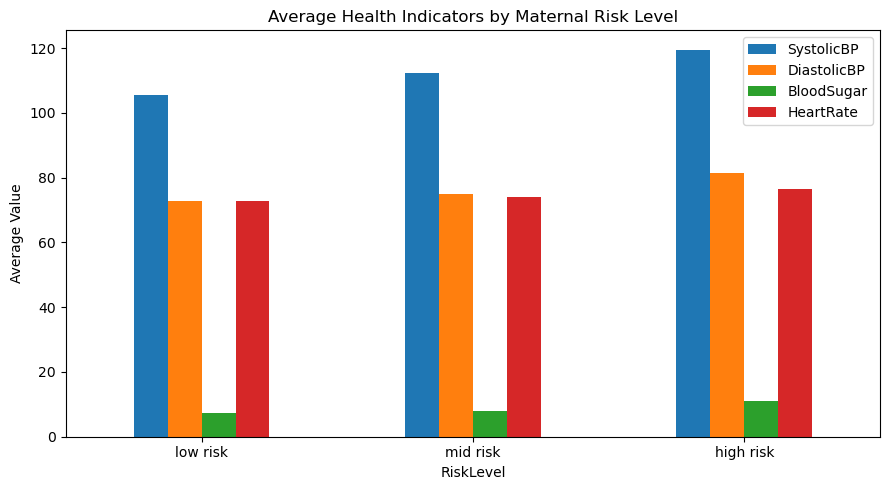

In [56]:
import matplotlib.pyplot as plt

ax = avg_df.plot(kind="bar", figsize=(9,5))

ax.set_title("Average Health Indicators by Maternal Risk Level")
ax.set_ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()

# Save the correct figure
ax.figure.savefig("health_indicator.png",
                  dpi=300,
                  bbox_inches="tight")

plt.show()

#### b) Age Distribution by Risk Level

Insight and Explanation:
+ The age distribution reveals that mothers classified as High Risk are more frequently represented in the older age groups, whereas Low Risk mothers are concentrated within younger age ranges. This finding suggests that maternal age may influence pregnancy outcomes, with advanced maternal age increasing the probability of developing pregnancy-related complications.
+ However, it is also evident that younger mothers are not entirely free from risk, indicating that age alone cannot determine maternal health status. Other physiological factors remain important when assessing pregnancy risk.

Recommendation:
+ Healthcare institutions should provide enhanced prenatal monitoring for women of advanced maternal age, particularly those above 35 years old. Additional screening programmes and more frequent antenatal check-ups should be introduced for older expectant mothers. At the same time, routine screening should continue for younger mothers because pregnancy complications may still occur regardless of age.

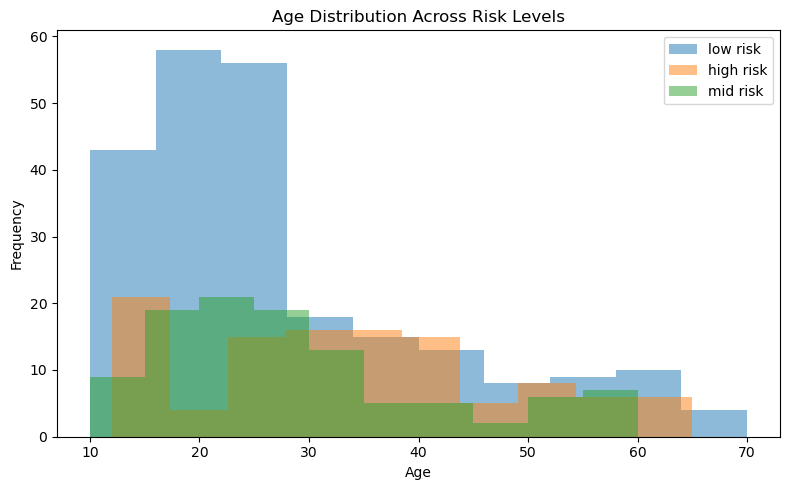

In [57]:
df = spark.table("maternal_risk").toPandas()  # Use data stored in Hive

fig, ax = plt.subplots(figsize=(8,5))

for level in df["RiskLevel"].unique():
    ax.hist(
        df[df["RiskLevel"] == level]["Age"],
        alpha=0.5,
        bins=10,
        label=level
    )

ax.legend()
ax.set_title("Age Distribution Across Risk Levels")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")

fig.tight_layout()

# Save the figure
fig.savefig("age_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

#### c) Blood Sugar vs Age

Insight and Explanation:
+ The scatter plot illustrates the relationship between maternal age and blood sugar levels while distinguishing patients by their risk category. High Risk cases tend to cluster in regions with elevated blood sugar levels, particularly among middle-aged and older mothers. Although there is no perfectly linear relationship between age and blood sugar, higher glucose levels are clearly associated with increased maternal risk.
+ The spread of data points also suggests that blood sugar alone is insufficient for predicting risk, reinforcing the importance of combining multiple clinical variables during maternal health assessment.

Recommendation:
+ Routine blood glucose screening should be incorporated into antenatal care regardless of maternal age. Healthcare providers should pay particular attention to patients who simultaneously exhibit elevated blood sugar levels and other abnormal health indicators, as they are more likely to experience pregnancy complications. Integrating predictive analytics into hospital information systems could further improve early identification of high-risk pregnancies.

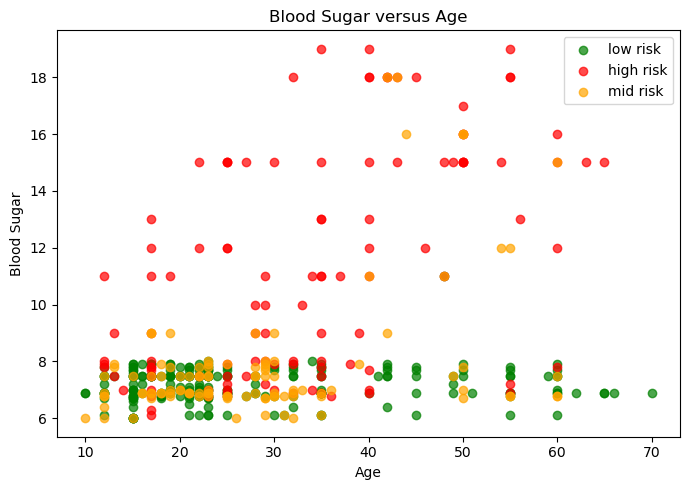

In [58]:
fig, ax = plt.subplots(figsize=(7,5))

colors = {
    "low risk": "green",
    "mid risk": "orange",
    "high risk": "red"
}

for risk in df["RiskLevel"].unique():
    subset = df[df["RiskLevel"] == risk]
    ax.scatter(
        subset["Age"],
        subset["BS"],
        label=risk,
        color=colors.get(risk.lower(), "blue"),  # Uses your color dictionary
        alpha=0.7
    )

ax.set_xlabel("Age")
ax.set_ylabel("Blood Sugar")
ax.set_title("Blood Sugar versus Age")
ax.legend()

fig.tight_layout()

# Save the figure
fig.savefig("blood_sugar_vs_age.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

#### d) Correlation heatmap

Insight and Explanation:
+ The correlation heatmap provides an overview of the relationships between the numerical health indicators. The strongest positive correlation is observed between systolic and diastolic blood pressure, indicating that increases in one measurement are generally accompanied by increases in the other. This is expected because both measurements assess cardiovascular function.
+ Other variables, such as body temperature and heart rate, show weaker correlations with the remaining health indicators, suggesting that they contribute independently rather than being directly related. The absence of extremely high correlations among most variables indicates that each feature provides unique information for assessing maternal health risk.

Recommendation:
+ Healthcare professionals should evaluate multiple clinical indicators simultaneously rather than relying on a single measurement. Predictive models developed using Spark ML or other machine learning frameworks can leverage the complementary information provided by these variables to improve maternal risk classification. Future healthcare systems should integrate multiple physiological measurements into a comprehensive decision-support system.

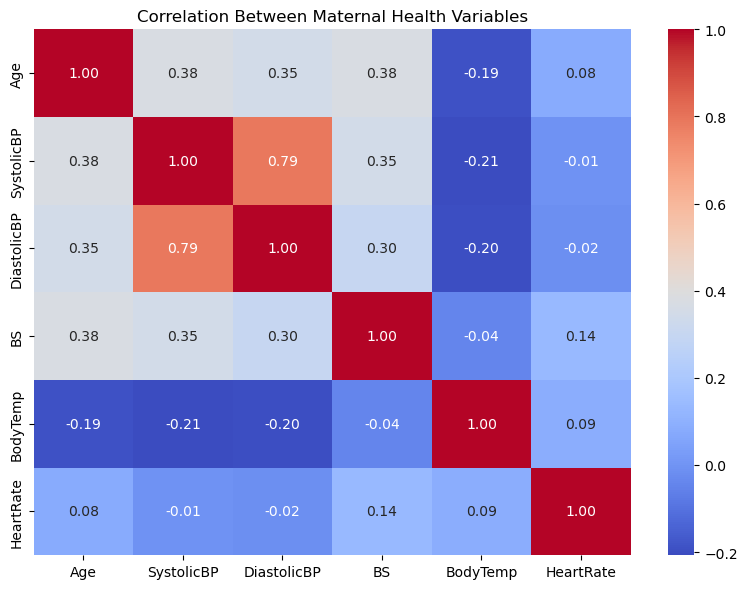

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[
    [
        "Age",
        "SystolicBP",
        "DiastolicBP",
        "BS",
        "BodyTemp",
        "HeartRate"
    ]
].corr()

fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=ax
)

ax.set_title("Correlation Between Maternal Health Variables")

fig.tight_layout()

# Save the figure
fig.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### e) Percentage of Mothers by Risk Level

Insight and Explanation:
+ The distribution of maternal risk levels provides an overview of the proportion of mothers classified into each risk category. If the High Risk category represents a significant proportion of the dataset, it highlights the importance of continuous maternal health surveillance and early intervention strategies. Conversely, if Low Risk cases dominate the dataset, it suggests that most pregnancies are relatively healthy while still emphasizing the need to identify the smaller group of vulnerable patients.
+ This visualization also helps healthcare administrators understand the overall burden of maternal risk within the studied population.
  
Recommendation:
+ Healthcare organizations should allocate resources proportionally to the prevalence of each risk category. If a considerable number of High Risk cases exist, hospitals should strengthen specialist maternal care services, improve patient monitoring systems, and provide additional healthcare personnel for high-risk pregnancies. Public health awareness programmes promoting healthy lifestyles during pregnancy may also contribute to reducing maternal risk.

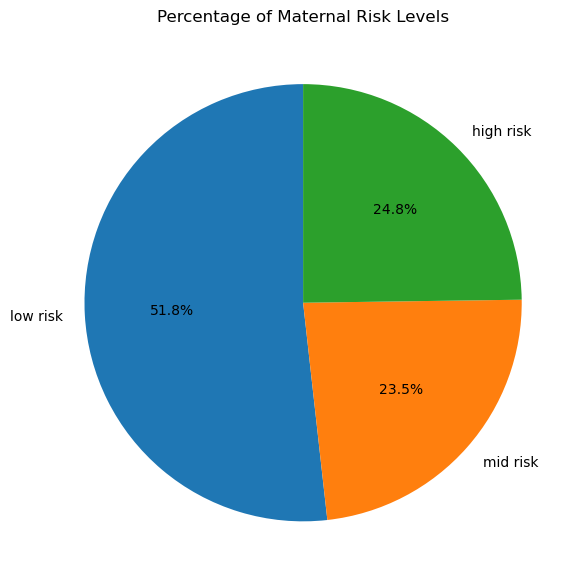

In [60]:
risk = spark.sql("""
SELECT RiskLevel, COUNT(*) AS Total
FROM maternal_risk
GROUP BY RiskLevel
""").toPandas()

fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    risk["Total"],
    labels=risk["RiskLevel"],
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title("Percentage of Maternal Risk Levels")

fig.tight_layout()

# Save the figure
fig.savefig(
    "risk_level_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### f) Boxplot of Blood Sugar by Risk Level

Insight and Explanation:
+ The boxplot illustrates the distribution of blood sugar levels within each maternal risk category. Compared to the average values shown in previous visualizations, the boxplot highlights the spread, median, and presence of outliers. The High Risk group generally exhibits a higher median blood sugar level and greater variability, indicating that many mothers experience significantly elevated glucose levels.
+ The presence of outliers further suggests that some patients have exceptionally high blood sugar readings, which may require immediate medical attention. This visualization demonstrates that relying solely on average values could overlook individual cases with severe abnormalities. 

Recommendation:
+ Healthcare providers should not only monitor average blood sugar levels but also identify patients with extreme glucose readings. Individualized treatment plans should be developed for mothers exhibiting abnormal blood sugar levels, including dietary counselling, lifestyle modifications, and closer medical supervision. Early intervention for these patients may reduce complications associated with gestational diabetes and improve pregnancy outcomes.

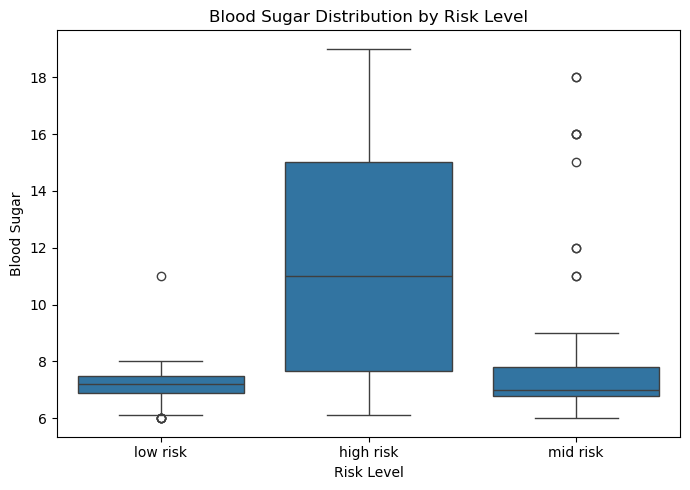

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7,5))

sns.boxplot(
    x="RiskLevel",
    y="BS",
    data=df,
    ax=ax
)

ax.set_title("Blood Sugar Distribution by Risk Level")
ax.set_xlabel("Risk Level")
ax.set_ylabel("Blood Sugar")

fig.tight_layout()

# Save the figure
fig.savefig(
    "blood_sugar_distribution_by_risk_level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Part 9: Overall Recommendations
+ The analytical findings demonstrate that maternal risk is influenced by multiple physiological indicators rather than a single health measurement. Blood pressure and blood sugar emerge as the most significant factors associated with higher maternal risk, while maternal age also contributes to increased vulnerability.
+ Therefore, healthcare providers should adopt a comprehensive monitoring approach that combines multiple health indicators for early risk assessment.
+ Furthermore, integrating big data technologies such as Apache Spark and Hive into healthcare information systems can enable efficient processing of large-scale maternal health records, support real-time risk monitoring, and facilitate timely clinical decision-making to improve maternal and neonatal outcomes.

## Part 10: Conclusion
+ This project successfully demonstrated the use of Apache Spark, Spark SQL and Apache Hive process and analyse maternal health data in a distributed environment. The analytical results showed that higher blood pressure, elevated blood sugar levels, and older maternal age are associated with increased maternal risk. The proposed big data pipeline effectively handled data ingestion, storage, querying, and analysis, illustrating the suitability of distributed technologies for healthcare analytics. Overall, the project highlights how big data frameworks can support healthcare professionals in identifying high-risk pregnancies and improving maternal care through data-driven decision-making.